In [1]:
from datasets import load_dataset

# Using sample-10BT for manageability; swap name for a specific CC dump
# (e.g. 'CC-MAIN-2024-46') or remove name entirely for the full 25.9B-row dataset
fw = load_dataset("HuggingFaceFW/fineweb", name="sample-10BT", streaming=True)

Resolving data files:   0%|          | 0/27468 [00:00<?, ?it/s]

## Exploratory Analysis

In [2]:
# Peek at the first record to see available fields
sample = next(iter(fw["train"]))
print("Fields:", list(sample.keys()))
print()
for k, v in sample.items():
    preview = str(v)[:200] + "..." if len(str(v)) > 200 else str(v)
    print(f"  {k}: {preview}")

Fields: ['text', 'id', 'dump', 'url', 'date', 'file_path', 'language', 'language_score', 'token_count']

  text: |Viewing Single Post From: Spoilers for the Week of February 11th|
|Lil||Feb 1 2013, 09:58 AM|
Don't care about Chloe/Taniel/Jen-Jen. Don't care about Sami, really, but hoping that we get some good "S...
  id: <urn:uuid:39147604-bfbe-4ed5-b19c-54105f8ae8a7>
  dump: CC-MAIN-2013-20
  url: http://daytimeroyaltyonline.com/single/?p=8906650&t=8780053
  date: 2013-05-18T05:48:59Z
  file_path: s3://commoncrawl/crawl-data/CC-MAIN-2013-20/segments/1368696381249/warc/CC-MAIN-20130516092621-00000-ip-10-60-113-184.ec2.internal.warc.gz
  language: en
  language_score: 0.8232095837593079
  token_count: 142


Sampled 5000 records


/var/folders/t4/gn3h1ztn34zdb3_pr42cbzr00000gn/T/ipykernel_54579/3970377861.py:25: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  by_ym   = s.dt.to_period("M").value_counts().sort_index()


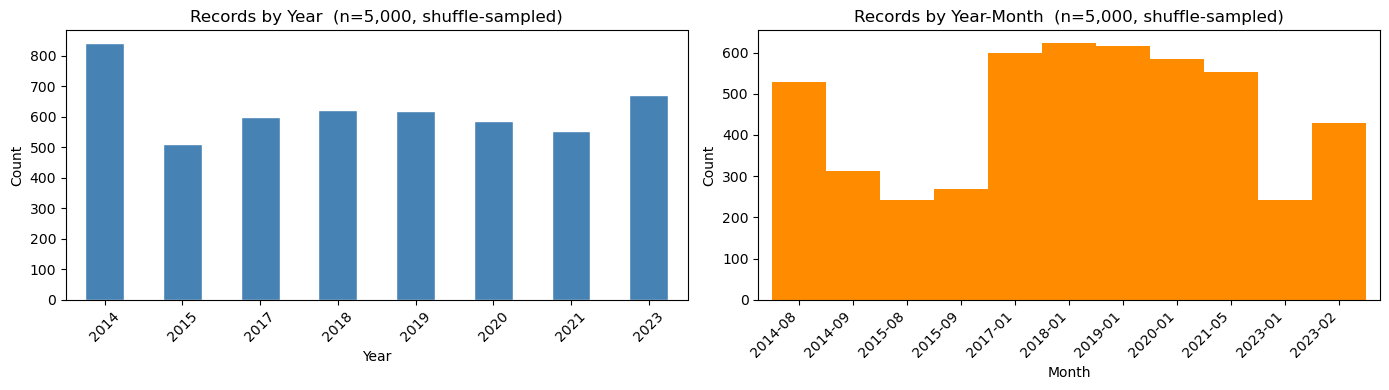

In [3]:
import random
import pandas as pd
import matplotlib.pyplot as plt

# .shard() does not exist on IterableDataset. Use shuffle+take instead:
# one pass through the stream, works regardless of the underlying file count.
TOTAL_SAMPLE = 5_000
BUFFER_SIZE  = 10_000
SEED         = 42

shuffled_ds = fw["train"].shuffle(buffer_size=BUFFER_SIZE, seed=SEED)

timestamps = []
for record in shuffled_ds.take(TOTAL_SAMPLE):
    ts = record.get("date")
    if ts:
        timestamps.append(ts)

print(f"Sampled {len(timestamps)} records")

# Parse timestamps (ISO format)
dates = pd.to_datetime(timestamps, utc=True)
s = pd.Series(dates)
by_year = s.dt.year.value_counts().sort_index()
by_ym   = s.dt.to_period("M").value_counts().sort_index()

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

by_year.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title(f"Records by Year  (n={len(timestamps):,}, shuffle-sampled)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

by_ym_ts = by_ym.copy()
by_ym_ts.index = by_ym_ts.index.to_timestamp()
by_ym_ts.plot(kind="bar", ax=axes[1], color="darkorange", edgecolor="none", width=1.0)
axes[1].set_title(f"Records by Year-Month  (n={len(timestamps):,}, shuffle-sampled)")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Count")
n_ticks = len(by_ym_ts)
step = max(1, n_ticks // 12)
axes[1].set_xticks(range(0, n_ticks, step))
axes[1].set_xticklabels(
    [f"{by_ym_ts.index[i].year}-{str(by_ym_ts.index[i].month).zfill(2)}"
     for i in range(0, n_ticks, step)],
    rotation=45, ha="right"
)

plt.tight_layout()
plt.show()

In [4]:
# Date range and distribution stats
print("=== Date Range ===")
print(f"  Earliest : {s.min()}")
print(f"  Latest   : {s.max()}")
print(f"  Span     : {s.max() - s.min()}")
print()
print("=== Distribution by Year ===")
for year, count in by_year.items():
    bar = "\u2588" * (count * 40 // by_year.max())
    print(f"  {year}  {count:>6}  {bar}")
print()
print("=== Distribution by Month (all years combined) ===")
by_month = s.dt.month.value_counts().sort_index()
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
for month, count in by_month.items():
    bar = "\u2588" * (count * 40 // by_month.max())
    print(f"  {month_names[month-1]}  {count:>6}  {bar}")

=== Date Range ===
  Earliest : 2014-08-20 04:49:46+00:00
  Latest   : 2023-02-09 13:33:54+00:00
  Span     : 3095 days 08:44:08

=== Distribution by Year ===
  2014     841  ████████████████████████████████████████
  2015     511  ████████████████████████
  2017     600  ████████████████████████████
  2018     623  █████████████████████████████
  2019     617  █████████████████████████████
  2020     585  ███████████████████████████
  2021     552  ██████████████████████████
  2023     671  ███████████████████████████████

=== Distribution by Month (all years combined) ===
  Jan    2668  ████████████████████████████████████████
  Feb     428  ██████
  May     552  ████████
  Aug     771  ███████████
  Sep     581  ████████
